In [1]:
import os
import shutil
import random
import tqdm
import torch
import torch.nn.functional as ff
import torchaudio
import torchaudio.transforms as tt
import matplotlib.pyplot as plt
import pandas as pd

___

## Cut Dataset into Segments

In [2]:
ROOT_SRC = '/home/ovistetom/Documents/data/EARS/original'
ROOT_DST = '/home/ovistetom/Documents/data/EARS/preprocessed'
SAMPLE_RATE = 16000
DEVICE = torch.device('cpu' if torch.cuda.is_available() else 'cpu')
os.makedirs(ROOT_DST, exist_ok=True)

In [3]:
list_speakers = os.listdir(ROOT_SRC)
num_speakers = len(list_speakers)
random.shuffle(list_speakers)
print(list_speakers[:10])

['p036', 'p048', 'p029', 'p010', 'p105', 'p022', 'p023', 'p091', 'p077', 'p107']


In [4]:
tst_size = int(0.1*num_speakers)
val_size = int(0.1*num_speakers)
trn_size = num_speakers - val_size - tst_size
list_trn = list_speakers[:trn_size]
list_val = list_speakers[trn_size:trn_size+val_size]
list_tst = list_speakers[trn_size+val_size:]
print(len(list_trn), len(list_val), len(list_tst))

87 10 10


In [5]:
# Slicing parameters.
MAX_DURATION_SEGMENT = 18
MAX_SAMPLES_SEGMENT = MAX_DURATION_SEGMENT * SAMPLE_RATE
MIN_DURATION_SEGMENT = 6
MIN_SAMPLES_SEGMENT = MIN_DURATION_SEGMENT * SAMPLE_RATE
WIN_SIZE = 4096

In [6]:
RESAMPLER = tt.Resample(orig_freq=48000, new_freq=SAMPLE_RATE)
FADER = tt.Fade(fade_in_len=256, fade_out_len=256)
#STFT = tt.Spectrogram(**stft_kwargs, power=None)
#ISTFT = tt.InverseSpectrogram(**stft_kwargs)

In [7]:
def find_closest_multiple_of_ref(x, ref, round_up=False):
    return ref * ((x//ref)+round_up)

In [8]:
def find_slice_index(waveform, min_duration_segment, max_duration_segment, win_size=4096, sr=SAMPLE_RATE):
    """Take audio waveform. Return index where to slice."""
    
    min_samples_segment = int(min_duration_segment * sr)
    max_samples_segment = int(max_duration_segment * sr)

    hop_size = win_size//4
    waveform_power = torch.ones_like(waveform)
    for t in range(0, waveform.size(0)-win_size, hop_size):
        waveform_power[t:t+hop_size] = waveform[t:t+win_size].pow(2).sum()/win_size
    
    #waveform_power_smoothed = (1/3)*(waveform_power + ff.pad(waveform_power[win_size:], (0, win_size)) + ff.pad(waveform_power[:-win_size], (win_size, 0)))

    index_lowest_power_window = waveform_power[min_samples_segment:max_samples_segment].argmin() + min_samples_segment + win_size//2
    return index_lowest_power_window



In [9]:
for name_subset, list_subset in zip(['trn', 'val', 'tst'], [list_trn, list_val, list_tst]):
    
    path_subset_dst = os.path.join(ROOT_DST, name_subset)
    os.makedirs(path_subset_dst, exist_ok=True)

    for name_speaker in tqdm.tqdm(list_subset):

        path_speaker_src = os.path.join(ROOT_SRC, name_speaker)

        count_sample = 0
        for name_sample in sorted(os.listdir(path_speaker_src)):

            path_sample_src = os.path.join(path_speaker_src, name_sample)
            waveform, sr = torchaudio.load(uri=path_sample_src, normalize=True, channels_first=True)
            waveform = waveform[0]
            waveform = waveform / waveform.abs().max()

            if waveform.mean() > 0.01:
                waveform = waveform - waveform.mean()

            if sr != SAMPLE_RATE:
                assert sr == 48000, f"Sample rate {sr} not supported."
                waveform = RESAMPLER(waveform)
                waveform = torchaudio.functional.highpass_biquad(
                    waveform=waveform,
                    sample_rate=SAMPLE_RATE,
                    cutoff_freq=70.0,
                )

            if waveform.size(0) < MAX_SAMPLES_SEGMENT:
                list_waveforms = [waveform]
            else:
                list_waveforms = []
                running_waveform = waveform.clone()

                while running_waveform.size(0) > MAX_SAMPLES_SEGMENT:
                    cut_index = find_slice_index(
                        running_waveform, 
                        min_duration_segment = MIN_DURATION_SEGMENT, 
                        max_duration_segment = MAX_DURATION_SEGMENT - MIN_DURATION_SEGMENT,
                        win_size = WIN_SIZE,
                    )
                    clip_waveform = running_waveform[:cut_index].clone()
                    list_waveforms.append(clip_waveform)
                    running_waveform = running_waveform[cut_index:].clone()

                if running_waveform.size(0) > MIN_SAMPLES_SEGMENT:
                    cut_index = find_closest_multiple_of_ref(x=running_waveform.size(0), ref=WIN_SIZE//2, round_up=False)
                    list_waveforms.append(running_waveform[:cut_index].clone())

            for s in list_waveforms:
                path_sample_dst = os.path.join(path_subset_dst, f"{name_speaker}_{count_sample:03d}.flac")
                s = FADER(s).unsqueeze(0)
                s = s / s.abs().max()
                torchaudio.save(uri=path_sample_dst, src=s, sample_rate=SAMPLE_RATE, channels_first=True)
                count_sample += 1


100%|██████████| 10/10 [01:37<00:00,  9.74s/it]


___

## Analyse Dataset

In [10]:
ROOT_DB = os.path.join(ROOT_DST, 'trn')

list_waveform_length = []
list_waveform_power = []
for sample_name in os.listdir(ROOT_DB):
    sample_path = os.path.join(ROOT_DB, sample_name)
    waveform, sr = torchaudio.load(uri=sample_path, normalize=True, channels_first=True)
    list_waveform_length.append(waveform.size(1) / sr)
    list_waveform_power.append((waveform.pow(2).sum() / waveform.size(1)).log().item())

print(f"Num. samples: {len(list_waveform_length)}")

Num. samples: 26712


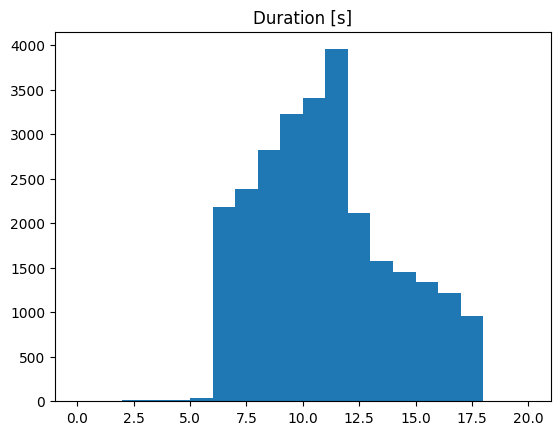

In [11]:
fig, axs = plt.subplots(1,1)
axs.hist(list_waveform_length, bins=20, range=(0, 20))
axs.set_title('Duration [s]')
plt.show()

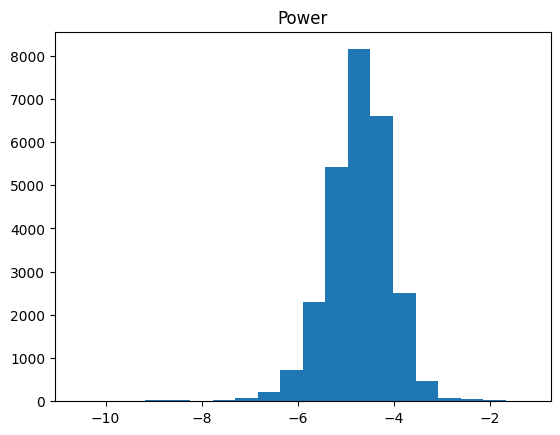

In [12]:
fig, axs = plt.subplots(1,1)
axs.hist(list_waveform_power, bins=20)
axs.set_title('Power')
plt.show()

___